# RepeatRadar Cohort Visualization Tutorial

## Welcome to Cohort Visualization with RepeatRadar!

This comprehensive tutorial demonstrates how to create insightful visualizations from cohort data using the `repeatradar` package. You'll learn to:

- 📊 Create interactive cohort heatmaps
- 📈 Generate retention curve visualizations  
- 🎨 Customize chart styling and formatting
- 💡 Interpret visualization patterns and insights
- 📁 Export charts for presentations and reports

**Core Visualization Functions:**
- **`plot_cohort_heatmap()`**: Interactive heatmaps showing cohort performance patterns
- **`plot_retention_curves()`**: Line charts comparing retention behavior across cohorts

Let's start creating powerful visualizations!

In [14]:
# Install RepeatRadar if needed
# Uncomment the line below if you haven't installed the package yet
# !pip install repeatradar --upgrade

In [15]:
# Import the package and check version
import repeatradar

# Note: If you're working with the development version, version might not be available
try:
    print(f"RepeatRadar version: {repeatradar.__version__}")
except AttributeError:
    print("RepeatRadar is not installed or the version is not available. Install it using 'pip install repeatradar --upgrade'.")

RepeatRadar version: 0.6.0


In [16]:
# Import the visualization functions and required libraries
from repeatradar import (
    generate_cohort_data,
    plot_cohort_heatmap,
    plot_retention_curves
)
import pandas as pd
import numpy as np
from datetime import datetime

# Display settings for better output
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
pd.set_option('display.width', None)

## 🚀 Getting Started

### Visualization Workflow

The RepeatRadar visualization process follows this simple workflow:

1. **Load Data** → Import your transactional/user activity data
2. **Generate Cohorts** → Use `generate_cohort_data()` to create cohort tables
3. **Create Visualizations** → Use visualization functions to reveal insights
4. **Customize & Export** → Adjust styling and export for reports

### Key Features of RepeatRadar Visualizations

- **Interactive**: All charts use Plotly for zoom, hover, and pan capabilities
- **Professional**: Clean, publication-ready design with customizable styling
- **Flexible**: Works with user counts, revenue data, retention rates, and custom metrics
- **Export-Ready**: Save as PNG, HTML, or PDF for presentations and reports

Let's start by loading our sample dataset!

In [17]:
# Load the sample e-commerce dataset
ecommerce_data = pd.read_pickle("https://github.com/krinya/repeatradar/raw/refs/heads/main/examples/data/ecommerce_data_1.pkl")

print(f"📊 Dataset Overview:")
print(f"{ecommerce_data.shape[0]:,} transactions from {ecommerce_data['CustomerID'].nunique():,} customers")
print(f"📅 Date range: {ecommerce_data['InvoiceDateTime'].min().strftime('%Y-%m-%d')} to {ecommerce_data['InvoiceDateTime'].max().strftime('%Y-%m-%d')}")
print(f"💰 Total revenue: ${ecommerce_data['TotalPrice'].sum():,.2f}")

📊 Dataset Overview:
401,604 transactions from 4,372 customers
📅 Date range: 2010-12-01 to 2011-12-09
💰 Total revenue: $8,278,519.42


## 1️⃣ Generating Cohort Data for Visualization

Before creating visualizations, we need to generate cohort data. We'll create three different types:

### Data Types for Visualization:
1. **User Count Cohorts**: Track how many unique users are active in each period
2. **Revenue Cohorts**: Track revenue generated by each cohort over time  
3. **Retention Rate Cohorts**: Track the percentage of users who remain active

Each type provides different insights into customer behavior patterns.

In [18]:
# Generate User Count Cohorts
user_cohorts = generate_cohort_data(
    data=ecommerce_data,
    date_column='InvoiceDateTime',
    user_column='CustomerID',
    cohort_period='M',           # Monthly cohorts
    period_duration=30,          # 30-day analysis periods
    output_format='pivot'        # Pivot format for heatmaps
)

print(f"User cohorts generated: {user_cohorts.shape[0]} cohorts × {user_cohorts.shape[1]} periods")
print(f"User range: {user_cohorts.values.min():.0f} to {user_cohorts.values.max():.0f} users")
user_cohorts.head()

User cohorts generated: 13 cohorts × 13 periods
User range: 0 to 948 users


period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_period,,,,,,,,,,,,,
2010-12-01,948,352,334,370,326,358,355,331,330,366,382,476,182
2011-01-01,421,107,118,127,126,124,102,113,139,144,131,13,0
2011-02-01,380,84,92,110,80,100,91,112,107,100,12,0,0
2011-03-01,440,81,106,100,89,89,110,117,97,20,0,0,0
2011-04-01,299,80,54,66,54,69,74,72,10,0,0,0,0


In [19]:
# Generate Revenue Cohorts
revenue_cohorts = generate_cohort_data(
    data=ecommerce_data,
    date_column='InvoiceDateTime',
    user_column='CustomerID',
    value_column='TotalPrice',      # Track revenue
    aggregation_function='sum',     # Sum revenue per cohort/period
    cohort_period='M',
    period_duration=30,
    output_format='pivot'
)

print(f"Revenue cohorts generated: {revenue_cohorts.shape[0]} cohorts × {revenue_cohorts.shape[1]} periods")
print(f"Revenue range: ${revenue_cohorts.values.min():,.0f} to ${revenue_cohorts.values.max():,.0f}")
revenue_cohorts.head()

Revenue cohorts generated: 13 cohorts × 13 periods
Revenue range: $0 to $589,533


period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_period,,,,,,,,,,,,,
2010-12-01,589533.180,269399.16,234009.12,311793.00,209192.20,298263.34,315586.11,332821.53,287860.590,459076.60,450068.79,491361.96,152318.74
2011-01-01,217959.240,76221.67,50863.08,60313.78,73463.41,83480.05,60478.38,86223.89,78520.991,94758.53,106628.67,9581.39,0.00
2011-02-01,158592.820,34747.95,39150.70,43757.82,28229.15,37402.11,41966.76,58180.63,58234.550,43298.00,5255.28,0.00,0.00
2011-03-01,202336.500,30528.95,51142.47,42600.30,43798.22,42942.82,58424.96,66458.42,49548.580,4472.77,0.00,0.00,0.00
2011-04-01,126913.811,31787.90,21765.42,24104.94,21972.97,30471.89,34360.73,26274.30,3037.780,0.00,0.00,0.00,0.00


In [20]:
# Generate Retention Rate Cohorts
retention_cohorts = generate_cohort_data(
    data=ecommerce_data,
    date_column='InvoiceDateTime',
    user_column='CustomerID',
    cohort_period='M',
    period_duration=30,
    calculate_retention_rate=True,  # This gives us percentages
    output_format='pivot'
)

print(f"Retention cohorts generated: {retention_cohorts.shape[0]} cohorts × {retention_cohorts.shape[1]} periods")
print(f"Retention range: {retention_cohorts.values.min():.1f}% to {retention_cohorts.values.max():.1f}%")
retention_cohorts.head().round(1)

Retention cohorts generated: 13 cohorts × 13 periods
Retention range: 0.0% to 100.0%


period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_period,,,,,,,,,,,,,
2010-12-01,100.0,37.099998,35.200001,39.000000,34.400002,37.799999,37.400002,34.900002,34.799999,38.599998,40.299999,50.200001,19.200001
2011-01-01,100.0,25.400000,28.000000,30.200001,29.900000,29.400000,24.200001,26.799999,33.000000,34.200001,31.100000,3.100000,0.000000
2011-02-01,100.0,22.100000,24.200001,29.000000,21.000000,26.299999,24.000000,29.500000,28.200001,26.299999,3.200000,0.000000,0.000000
2011-03-01,100.0,18.400000,24.100000,22.700001,20.200001,20.200001,25.000000,26.600000,22.000000,4.600000,0.000000,0.000000,0.000000
2011-04-01,100.0,26.799999,18.100000,22.100000,18.100000,23.100000,24.799999,24.100000,3.300000,0.000000,0.000000,0.000000,0.000000


## 2️⃣ Cohort Heatmaps

**Heatmaps are the gold standard for cohort visualization!** They display your cohort data as a triangle where:

- **Rows** = Cohorts (acquisition periods)
- **Columns** = Analysis periods (0, 1, 2, 3...)
- **Colors** = Values (intensity represents magnitude)
- **Pattern** = The triangular shape reveals behavior patterns over time

### Perfect for:
- Quick pattern recognition across all cohorts
- Identifying strong/weak cohorts at a glance
- Spotting seasonal effects or trends
- Comparing performance across time periods

### Key Parameters:
- `color_scale`: Choose your color scheme ("Blues", "Viridis", "RdYlBu", etc.)
- `show_values`: Display actual numbers on cells
- `value_format`: Format the displayed numbers (.0f, .1f, etc.)
- `title`: Custom title for your heatmap

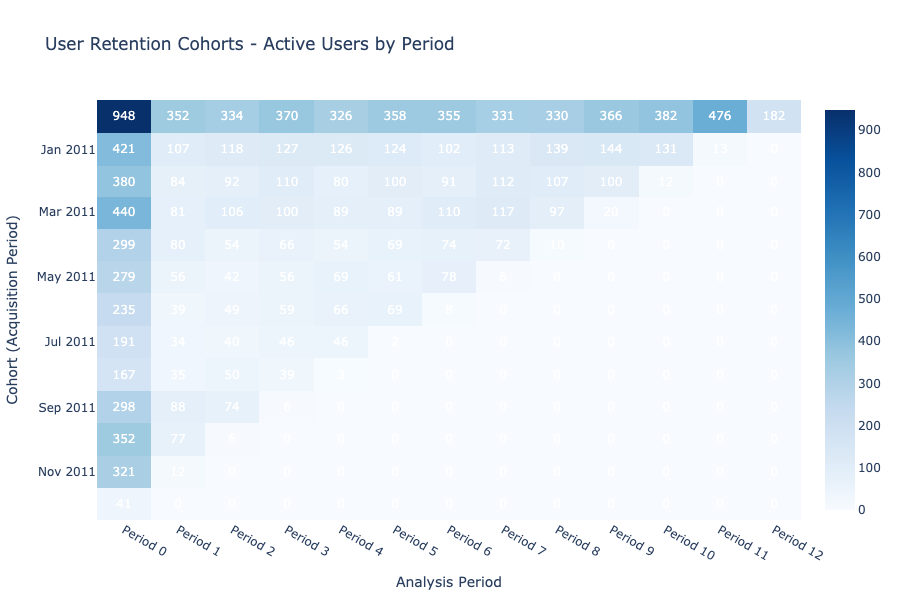


Insights from User Count Heatmap:
• Dark blue = High user activity
• Light blue = Lower user activity
• Triangle shape shows natural cohort aging
• First column (Period 0) shows acquisition size
• Subsequent columns show retention patterns


In [21]:
# Create User Count Heatmap
user_heatmap = plot_cohort_heatmap(
    cohort_data=user_cohorts,
    title="User Retention Cohorts - Active Users by Period",
    color_scale="Blues",        # Classic blue color scheme
    show_values=True,           # Show numbers on cells
    value_format=".0f",        # No decimal places for user counts
    show_colorscale=True,       # Show the color scale legend
    width=900,
    height=600
)

# Display the interactive heatmap
user_heatmap.show('png') #for github able to display

print("\nInsights from User Count Heatmap:")
print("• Dark blue = High user activity")
print("• Light blue = Lower user activity") 
print("• Triangle shape shows natural cohort aging")
print("• First column (Period 0) shows acquisition size")
print("• Subsequent columns show retention patterns")

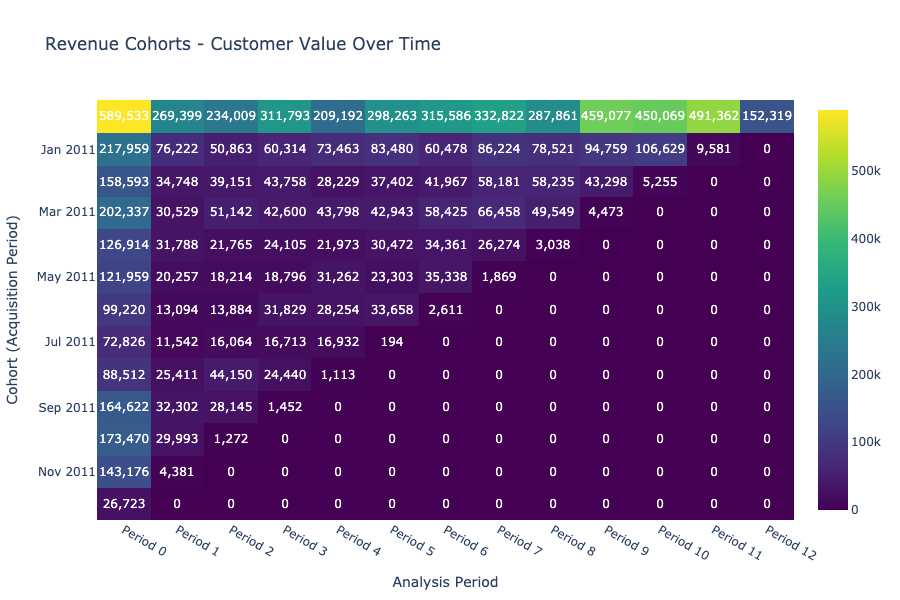


Revenue Heatmap Insights:
• Bright colors = High revenue periods
• Dark colors = Lower revenue periods
• Compare cohort lifetime values
• Identify high-value acquisition periods
• Spot revenue retention patterns


In [22]:
# Create Revenue Heatmap
revenue_heatmap = plot_cohort_heatmap(
    cohort_data=revenue_cohorts,
    title="Revenue Cohorts - Customer Value Over Time",
    color_scale="Viridis",       # Green-blue-purple scheme great for revenue
    show_values=True,
    value_format=",.0f",        # Comma-separated for large numbers
    show_colorscale=True,
    width=900,
    height=600
)

revenue_heatmap.show('png')

print("\nRevenue Heatmap Insights:")
print("• Bright colors = High revenue periods")
print("• Dark colors = Lower revenue periods") 
print("• Compare cohort lifetime values")
print("• Identify high-value acquisition periods")
print("• Spot revenue retention patterns")

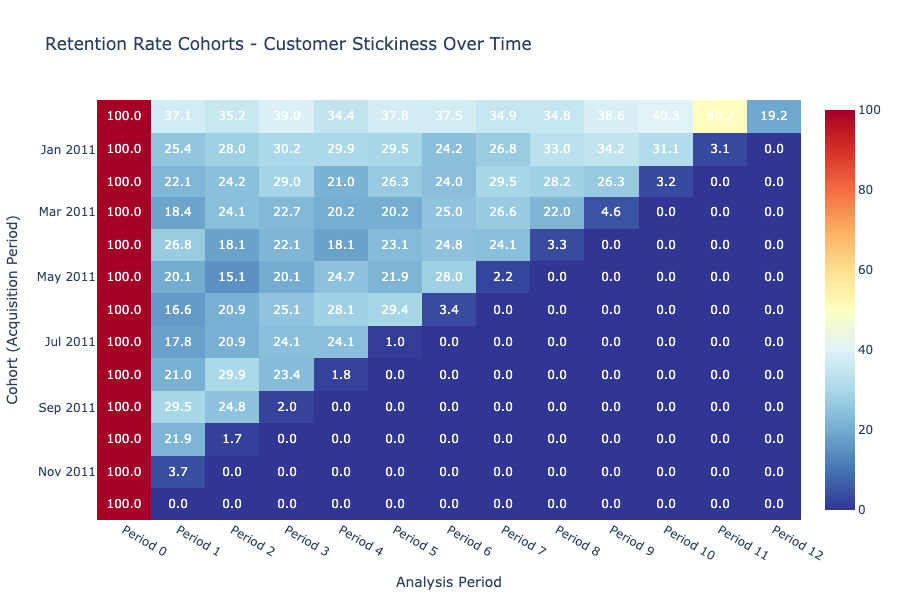


Retention Rate Insights:
• Blue = High retention rates (good!)
• Red = Low retention rates (needs attention)
• Period 0 is always 100% (baseline)
• Period 1 shows immediate retention
• Later periods show long-term loyalty


In [23]:
# Create Retention Rate Heatmap  
retention_heatmap = plot_cohort_heatmap(
    cohort_data=retention_cohorts,
    title="Retention Rate Cohorts - Customer Stickiness Over Time",
    color_scale="RdYlBu_r",     # Red-Yellow-Blue reversed (red=low, blue=high)
    show_values=True,
    value_format=".1f",        # One decimal place for percentages
    show_colorscale=True,
    width=900,
    height=600
)

retention_heatmap.show('png')

print("\nRetention Rate Insights:")
print("• Blue = High retention rates (good!)")
print("• Red = Low retention rates (needs attention)")
print("• Period 0 is always 100% (baseline)")
print("• Period 1 shows immediate retention")
print("• Later periods show long-term loyalty")

## 3️⃣ Retention Curves

**Retention curves show the customer journey over time!** These line charts reveal:

- How quickly customers drop off after acquisition
- Which cohorts have better long-term retention  
- Seasonal patterns in customer behavior
- The "shape" of your retention curve (steep drop vs. gradual decline)

### Perfect for:
- Comparing cohort performance side-by-side
- Identifying retention patterns and trends
- Measuring the impact of product changes
- Benchmarking against industry standards

### Key Parameters:
- `max_cohorts`: Limit display to most recent cohorts for clarity
- `show_legend`: Toggle cohort labels on/off
- `title`: Custom chart title
- `width/height`: Chart dimensions for presentations

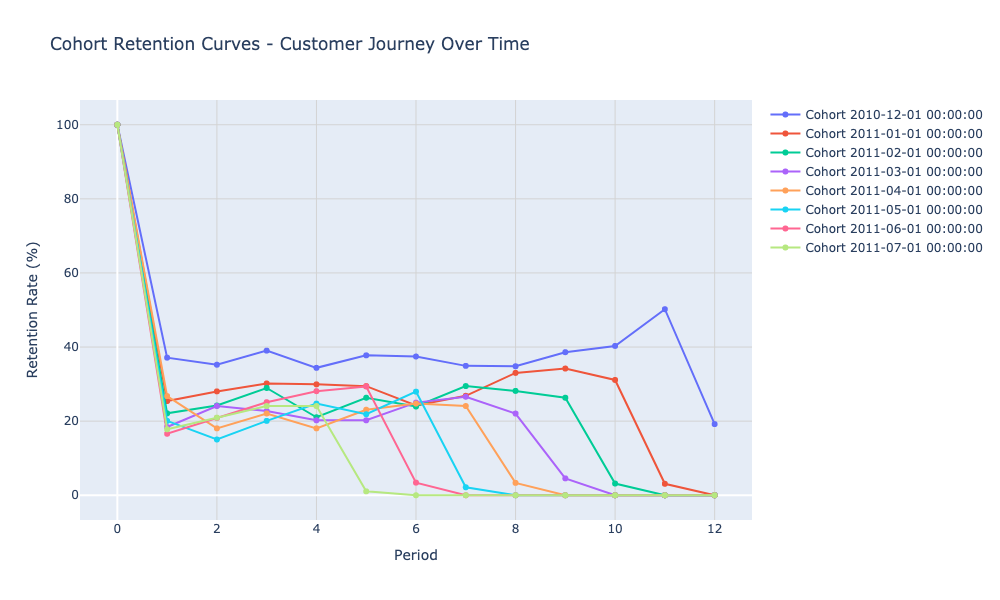


Retention Curve Analysis:
• Each line represents a different cohort
• X-axis = Time periods after acquisition
• Y-axis = Retention rate (%)
• Steeper drops = Faster customer churn
• Flatter curves = Better long-term retention
• Lines converging = Stable retention patterns


In [24]:
# Create Retention Curves
retention_curves = plot_retention_curves(
    retention_data=retention_cohorts,
    title="Cohort Retention Curves - Customer Journey Over Time",
    show_legend=True,           # Show cohort labels
    max_cohorts=8,              # Focus on 8 most recent cohorts
    width=1000,
    height=600
)

retention_curves.show('png')

print("\nRetention Curve Analysis:")
print("• Each line represents a different cohort")
print("• X-axis = Time periods after acquisition")
print("• Y-axis = Retention rate (%)")
print("• Steeper drops = Faster customer churn")
print("• Flatter curves = Better long-term retention")
print("• Lines converging = Stable retention patterns")

## 4️⃣ Customization and Styling

RepeatRadar's visualization functions offer extensive customization options. Let's explore some advanced styling and formatting techniques for professional presentations.

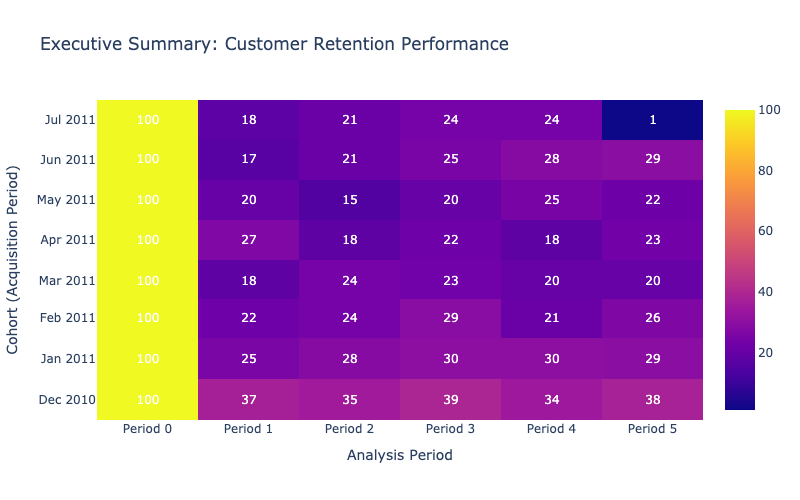


This heatmap is optimized for executive presentations!
• Compact size fits in reports
• Clear color scheme for business context
• Focused on key cohorts and periods


In [25]:
# Custom Styled Heatmap for Executive Reports
custom_heatmap = plot_cohort_heatmap(
    cohort_data=retention_cohorts.iloc[:8, :6],  # Focus on subset
    title="Executive Summary: Customer Retention Performance",
    color_scale="Plasma",         # Purple-pink-yellow scheme
    show_values=True,
    value_format=".0f",          # Show as whole percentages
    show_colorscale=True,
    width=800,                    # Compact size for reports
    height=500,
    reverse_y_axis=False          # Show oldest cohorts at top
)

custom_heatmap.show('png')

print("\nThis heatmap is optimized for executive presentations!")
print("• Compact size fits in reports")
print("• Clear color scheme for business context")
print("• Focused on key cohorts and periods")

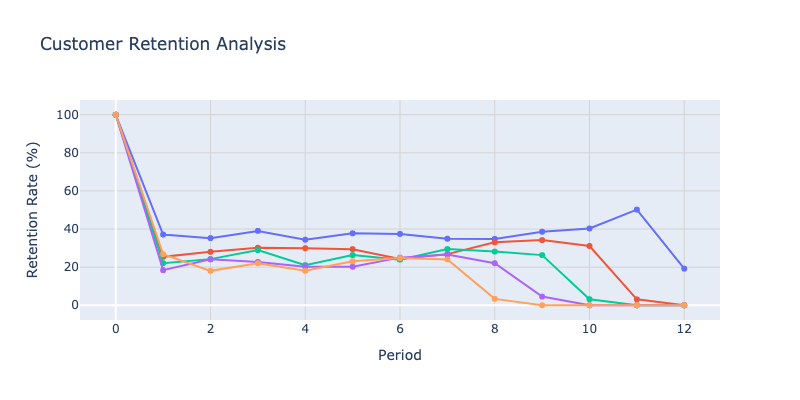


Perfect for including in reports and presentations!
• Clean design without visual clutter
• Focused on key cohorts for clarity
• Compact size for easy embedding


In [26]:
# Minimal Retention Curves for Reports
minimal_curves = plot_retention_curves(
    retention_data=retention_cohorts,
    title="Customer Retention Analysis",
    show_legend=False,            # Clean look without legend
    max_cohorts=5,               # Show only top 5 cohorts
    width=800,
    height=400
)

minimal_curves.show('png')

print("\nPerfect for including in reports and presentations!")
print("• Clean design without visual clutter")
print("• Focused on key cohorts for clarity") 
print("• Compact size for easy embedding")

## 5️⃣ Interpreting Your Visualizations

### What to Look for in Cohort Heatmaps

**Pattern Analysis:**
1. **Diagonal Patterns**: Consistent retention across cohorts indicates stable business
2. **Horizontal Patterns**: Specific time periods affecting all cohorts (seasonality, events)
3. **Color Intensity**: Identify your strongest and weakest performing cohorts
4. **Triangle Shape**: Natural aging pattern vs. concerning drops

**Business Insights:**
- **Dark first column**: Strong acquisition periods
- **Consistent color gradients**: Predictable retention behavior
- **Color outliers**: Cohorts that need investigation

### What to Look for in Retention Curves

**Curve Shape Analysis:**
1. **Initial Drop**: Steep drops in the first period are normal
2. **Stabilization**: Curves flattening indicates loyal customer segments
3. **Convergence**: Lines coming together suggest stable long-term patterns
4. **Outliers**: Cohorts performing significantly better/worse than others

**Trend Analysis:**
- **Improving trends**: Newer cohorts outperforming older ones
- **Declining trends**: Recent cohorts underperforming (needs attention)
- **Seasonal patterns**: Regular peaks and valleys in performance

### Pro Tips for Analysis

**Start with the Big Picture:**
- Use heatmaps for quick pattern recognition across all cohorts
- Use retention curves to compare specific cohorts in detail
- Combine both views for comprehensive analysis

**Focus on Actionable Insights:**
- Identify your best-performing cohorts and understand why
- Investigate poor-performing periods for learning opportunities
- Use trends to guide future marketing and product decisions

In [27]:
# Export Examples for Presentations and Reports
print("Chart export examples:")

# Save as HTML (interactive) - great for sharing and presentations
user_heatmap.write_html("user_retention_heatmap.html")
print("• Saved interactive heatmap as HTML")

# Save as PNG (static image) - requires kaleido: pip install kaleido
try:
    retention_curves.write_image("retention_curves.png", width=1000, height=600)
    print("• Saved retention curves as PNG")
except Exception as e:
    print(f"• PNG export requires 'kaleido' package: pip install kaleido")
    print(f"  Error: {e}")

print("\nFiles saved to current directory!")
print("\nExport Options:")
print("• HTML: Interactive charts for web sharing")
print("• PNG: Static images for documents")  
print("• PDF: Vector graphics for print")
print("• SVG: Scalable graphics for presentations")

Chart export examples:
• Saved interactive heatmap as HTML
• Saved retention curves as PNG

Files saved to current directory!

Export Options:
• HTML: Interactive charts for web sharing
• PNG: Static images for documents
• PDF: Vector graphics for print
• SVG: Scalable graphics for presentations


## 🎯 Conclusion

Congratulations! You've mastered RepeatRadar's core visualization functions.

### What You've Learned

**Visualization Techniques:**
- Created interactive cohort heatmaps for pattern recognition
- Generated retention curves for trend analysis
- Applied custom styling for professional presentations
- Exported charts for reports and sharing

**Analysis Skills:**
- Interpreted heatmap patterns and colors
- Analyzed retention curve shapes and trends
- Combined multiple visualization types for comprehensive insights
- Identified actionable business insights from visual patterns

### Next Steps

**Advanced Analysis:**
- Experiment with different color scales and formatting options
- Create visualizations for segmented customer groups
- Combine multiple metrics (revenue + retention) for deeper insights
- Set up automated reporting with exported charts

**Business Applications:**
- Use heatmaps for executive dashboards
- Include retention curves in marketing presentations
- Track the impact of product changes over time
- Benchmark performance against industry standards

### Additional Resources

- **Documentation**: Check the full API documentation for more customization options
- **Examples**: Explore the calculation demo notebook for data preparation techniques
- **Community**: Share your visualizations and learn from other RepeatRadar users

Happy analyzing! 📊